In [10]:
import torch
import os
import torch.nn as nn
from tqdm import tqdm
import json
import copy
from modules import *
from clearml import Task, Dataset
import os
from sklearn.model_selection import train_test_split



# Efficient/flash attention не поддерживают backward через backward (нужен для d2v в PINN).
# Math backend поддерживает произвольный порядок градиентов.
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)


MODELS_PATH = './'
DATASET_PATH = 'SimVascDataset'

SPLIT = {'train': [], 'val': [], 'test': []}

# SPLIT = {'train': ["0145_H_CORO_KD", "0151_H_AO_H"], 'val': [], 'test': []}

SPLIT['train'], SPLIT['val'] = train_test_split(os.listdir(DATASET_PATH), test_size=0.222, random_state=13)
SPLIT['val'], SPLIT['test'] = train_test_split(SPLIT['val'], test_size=0.5, random_state=13)

USE_EMB = True
ACT = 'wave'

INTERIOR_SIZE = 500
WALLS_SIZE    = 250
INLET_SIZE    = 100
OUTLET_SIZE   = 100
OUTERIOR_SIZE = 250

Q = 1.5e-6
S = 2e-6

# Границы срезов, вычисленные из констант датасета
_BND_START = INTERIOR_SIZE                                             # начало boundary (walls)
_BND_END   = INTERIOR_SIZE + WALLS_SIZE + INLET_SIZE + OUTLET_SIZE    # конец non-outerior

B = 8

RESUME_PINN = True
GEN_POINTS = True

class Dataset(torch.utils.data.Dataset):
    def __init__(self, path, split="train"):
        self.data = []
        for dir in os.listdir(path):
            if dir not in SPLIT[split]:
                continue
            for file in os.listdir(os.path.join(path, dir)):
                if (file.count('_') == 1) and (file.split('_')[-1] != '-1.stl') and ('.stl' in file):
                    if (GEN_POINTS) or (file.replace('.stl', '_interior.pt') in os.listdir(os.path.join(path, dir))):
                        self.data.append(load_stl(os.path.join(path, dir, file), odd=False, device='cuda', gen_p=GEN_POINTS))
                        torch.cuda.empty_cache()

        self.phi_stage = True


    def __getitem__(self, index):
        if index < len(self.data):
            inlet = 'inlet'
            outlet = 'outlet'
        else:
            index = index - len(self.data)
            inlet = 'outlet'
            outlet = 'inlet'

        agg = self.data[index]

        idx_int   = torch.randperm(len(agg['x_dict']['interior'][:(100000 if self.phi_stage else None)]))[:INTERIOR_SIZE]
        idx_w     = torch.randperm(len(agg['x_dict']['walls']))[:WALLS_SIZE]
        idx_in    = torch.randperm(len(agg['x_dict'][inlet]))[:INLET_SIZE]
        idx_out   = torch.randperm(len(agg['x_dict'][outlet]))[:OUTLET_SIZE]
        idx_outer = torch.randperm(len(agg['x_dict']['outerior']))[:OUTERIOR_SIZE]

        x = torch.cat([
            agg['x_dict']['interior'][idx_int],
            agg['x_dict']['walls'][idx_w],
            agg['x_dict'][inlet][idx_in],
            agg['x_dict'][outlet][idx_out],
            agg['x_dict']['outerior'][idx_outer],
        ], dim=0)

        # 0=interior, 1=walls, 2=inlet, 3=outlet, 4=outerior
        x_label = torch.cat([
            torch.zeros(INTERIOR_SIZE,             dtype=torch.long),
            torch.ones(WALLS_SIZE,                 dtype=torch.long),
            torch.full((INLET_SIZE,),    2,        dtype=torch.long),
            torch.full((OUTLET_SIZE,),   3,        dtype=torch.long),
            torch.full((OUTERIOR_SIZE,), 4,        dtype=torch.long),
        ])

        phi_w = torch.cat([
            agg['phi_w_dict']['interior'][idx_int] if self.phi_stage else agg['phi_w_dict']['interior'][:INTERIOR_SIZE],
            agg['phi_w_dict']['walls'][idx_w],
            agg['phi_w_dict'][inlet][idx_in],
            agg['phi_w_dict'][outlet][idx_out],
            agg['phi_w_dict']['outerior'][idx_outer],
        ])

        phi_key = "in" if inlet == 'inlet' else 'out'

        phi_in = torch.cat([
                agg[f'phi_{phi_key}_dict']['interior'][idx_int],
                agg[f'phi_{phi_key}_dict']['walls'][idx_w],
                agg[f'phi_{phi_key}_dict']['inlet'][idx_in],
                agg[f'phi_{phi_key}_dict']['outlet'][idx_out],
                agg[f'phi_{phi_key}_dict']['outerior'][idx_outer],
            ])

        norm_in    = agg['n_dict'][inlet]
        norm_out   = agg['n_dict'][outlet]
        center_in = agg['n_dict'][f'{inlet}_center']
        center_out = agg['n_dict'][f'{outlet}_center']

        l = agg['l']
        if inlet  == 'inlet':
            s = agg['s_in']
            v_mean = agg['v_mean_in']
        else:
            s = agg['s_out']
            v_mean = agg['v_mean_out']

        return x, torch.stack((phi_w, phi_in), 1), torch.cat((center_in, center_out)), norm_in.repeat(len(x), 1), norm_out.repeat(len(x), 1), center_out.repeat(len(x), 1), l.repeat(len(x), 1), s.repeat(len(x), 1), v_mean.repeat(len(x), 1), x_label

    def __len__(self):
        return len(self.data) * 2
    

dataset_train = Dataset(DATASET_PATH, "train")
dataset_val = Dataset(DATASET_PATH, "val")
dataset_test = Dataset(DATASET_PATH, "test")

1_1.stl
Outerior points generation with path: SimVascDataset\0018_H_AO_COA\1_1.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


1_2.stl
Outerior points generation with path: SimVascDataset\0018_H_AO_COA\1_2.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


1_3.stl
Outerior points generation with path: SimVascDataset\0018_H_AO_COA\1_3.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


1_4.stl
Outerior points generation with path: SimVascDataset\0018_H_AO_COA\1_4.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


1_5.stl
Outerior points generation with path: SimVascDataset\0018_H_AO_COA\1_5.stl
done

Interior points generation
done

Inlet points generatio

In [1]:
1528 / 1 * 8, 5667 / 3 * 8, 11220 / 6 * 8, 44880 / 6 * 2

(12224.0, 15112.0, 14960.0, 14960.0)

In [6]:
1128 / 6 * 64

12032.0

In [3]:
6*16

96

In [5]:
SPLIT

{'train': ['0181_H_ABAO_AAA',
  '0081_H_PULM_PAH',
  '0029_H_ABAO_H',
  '0042_H_ABAO_AAA',
  '0033_H_ABAO_AAA',
  '0032_H_ABAO_AAA',
  '0157_H_CORO_SVGD',
  '0063_H_PULMGLN_SVD',
  '0045_H_ABAO_AAA',
  '0124_H_PULM_WS',
  '0241_H_AO_COA',
  '0022_H_AO_MFS',
  '0218_H_CERE_CA',
  '0145_H_CORO_KD',
  '0118_H_PULM_WS',
  '0183_H_ABAO_AAA',
  '0151_H_AO_H',
  '0116_H_PULM_ALGS',
  '0101_A_AO_COA',
  '0018_H_AO_COA',
  '0209_H_CERE_CA',
  '0105_H_PULM_H',
  '0049_H_ABAO_AIOD',
  '0046_H_ABAO_AIOD',
  '0239_H_AO_COA',
  '0076_H_AO_H',
  '0025_H_AO_MFS',
  '0143_H_CORO_KD',
  '0208_H_CERE_CA',
  '0140_H_CORO_KD',
  '0192_H_ABAO_AAA',
  '0217_H_CERE_CA',
  '0096_A_AO_COA',
  '0047_H_ABAO_AIOD',
  '0099_A_AO_COA'],
 'val': ['0210_H_CERE_CA',
  '0225_H_AO_COA',
  '0098_A_AO_COA',
  '0238_H_AO_COA',
  '0187_H_ABAO_AAA'],
 'test': ['0086_H_PULM_PAH',
  '0153_H_AO_H',
  '0122_H_PULM_ALGS',
  '0233_H_AO_COA',
  '0038_H_ABAO_AAA']}

In [2]:
SPLIT

{'train': ['0181_H_ABAO_AAA',
  '0081_H_PULM_PAH',
  '0029_H_ABAO_H',
  '0042_H_ABAO_AAA',
  '0033_H_ABAO_AAA',
  '0032_H_ABAO_AAA',
  '0157_H_CORO_SVGD',
  '0063_H_PULMGLN_SVD',
  '0045_H_ABAO_AAA',
  '0124_H_PULM_WS',
  '0241_H_AO_COA',
  '0022_H_AO_MFS',
  '0218_H_CERE_CA',
  '0145_H_CORO_KD',
  '0118_H_PULM_WS',
  '0183_H_ABAO_AAA',
  '0151_H_AO_H',
  '0116_H_PULM_ALGS',
  '0101_A_AO_COA',
  '0018_H_AO_COA',
  '0209_H_CERE_CA',
  '0105_H_PULM_H',
  '0049_H_ABAO_AIOD',
  '0046_H_ABAO_AIOD',
  '0239_H_AO_COA',
  '0076_H_AO_H',
  '0025_H_AO_MFS',
  '0143_H_CORO_KD',
  '0208_H_CERE_CA',
  '0140_H_CORO_KD',
  '0192_H_ABAO_AAA',
  '0217_H_CERE_CA',
  '0096_A_AO_COA',
  '0047_H_ABAO_AIOD',
  '0099_A_AO_COA'],
 'val': ['0210_H_CERE_CA',
  '0225_H_AO_COA',
  '0098_A_AO_COA',
  '0238_H_AO_COA',
  '0187_H_ABAO_AAA'],
 'test': ['0086_H_PULM_PAH',
  '0153_H_AO_H',
  '0122_H_PULM_ALGS',
  '0233_H_AO_COA',
  '0038_H_ABAO_AAA']}

In [5]:
resume_task = Task.get_task(task_id="548bf0ed0e94495db87d5e444e04d52c",
    project_name='pershin-medailab/VLM_Embryo'
)

optimizer_path = resume_task.artifacts['finetuned_predictions'].get_local_copy()

2026-07-03 09:12:03,152 - clearml.storage - ERROR - Could not download s3://api.blackhole2.ai.innopolis.university:443/pershin-medailab/pershin-medailab/VLM_Embryo/medgemma-4b-finetuned-fold0-test-inference.548bf0ed0e94495db87d5e444e04d52c/artifacts/finetuned_predictions/predictions.jsonl , err: An error occurred (SlowDownRead) when calling the GetObject operation (reached max retries: 4): Resource requested is unreadable, please reduce your request rate 


In [2]:
GEN_POINTS = False
dataset = Dataset(DATASET_PATH)

Outerior points generation with path: SimVascDataset old\0145_H_CORO_KD\1_1.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset old\0145_H_CORO_KD\1_2.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset old\0145_H_CORO_KD\1_3.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset old\0145_H_CORO_KD\1_4.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset old\0145_H_CORO_KD\1_5.stl
done

Interior points generation
done

Inlet points generation
done

Outlet 

In [5]:
USE_EMB = True

import copy

def get_clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for i in range(N)])

ACT = 'wave'

def get_act():
    if ACT == 'wave':
        return WaveAct()
    elif ACT == 'tanh':
        return torch.nn.Tanh()
    elif ACT == 'silu':
        return nn.SiLU(inplace=True)

class WaveAct(nn.Module):
    def __init__(self):
        super(WaveAct, self).__init__() 
        self.w1 = nn.Parameter(torch.ones(1), requires_grad=True)
        self.w2 = nn.Parameter(torch.ones(1), requires_grad=True)

    def forward(self, x):
        return self.w1 * torch.sin(x) + self.w2 * torch.cos(x)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=256):
        super(FeedForward, self).__init__() 
        self.linear = nn.Sequential(*[
            nn.Linear(d_model, d_ff),
            get_act(),
            nn.Linear(d_ff, d_ff),
            get_act(),
            nn.Linear(d_ff, d_model)
        ])

    def forward(self, x):
        return self.linear(x)
    

class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(EncoderLayer, self).__init__()

        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = get_act()
        self.act2 = get_act()
        
    def forward(self, x):
        x2 = self.act1(x)
        x = x + self.attn(x2,x2,x2)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(DecoderLayer, self).__init__()

        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = get_act()
        self.act2 = get_act()

    def forward(self, x, e_outputs): 
        x2 = self.act1(x)
        x = x + self.attn(x2, e_outputs, e_outputs)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class Encoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Encoder, self).__init__()
        self.N = N
        self.layers = get_clones(EncoderLayer(d_model, heads), N)
        self.act = get_act()

    def forward(self, x):
        for i in range(self.N):
            x = self.layers[i](x)
        return self.act(x)


class Decoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Decoder, self).__init__()
        self.N = N
        self.layers = get_clones(DecoderLayer(d_model, heads), N)
        self.act = get_act()
        
    def forward(self, x, e_outputs):
        for i in range(self.N):
            x = self.layers[i](x, e_outputs)
        return self.act(x)


class GAPinn(nn.Module):
    def __init__(self, d_hidden=512, d_model=256, N=4, heads=8):
        super(GAPinn, self).__init__()

        if USE_EMB:
            self.embedding = nn.Embedding(5, d_model)

        self.linear_emb = nn.Linear(9, d_model)

        self.encoder = Encoder(d_model, N, heads)
        self.decoder_phi = Decoder(d_model, N, heads)
        # self.decoder_flow = Decoder(d_model, N, heads)

        self.linear_out_phi = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, 2)
        ])

        self.linear_out_v = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, 3)
        ])

        self.linear_out_p = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, 1)
        ])

    def forward(self, x, norm_in, norm_out, center_out, l, s, v_mean, x_label, pinn=False):

        B = x.shape[0]

        if pinn:
            x_grad = x * 2 * l
            # x_grad = x
            x_grad.requires_grad_(True)
            x_proj_enc = self.linear_emb(torch.cat((x_grad.clone().detach() / l / 2, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
            if USE_EMB:
                label_emb = self.embedding(x_label)        # (B, N, d_model)
                x_proj_enc = x_proj_enc + label_emb
            
            x_proj_dec = self.linear_emb(torch.cat((x_grad / l / 2, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
            # x_proj_enc = self.linear_emb(torch.cat((x_grad.clone().detach(), out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
            # x_proj_dec = self.linear_emb(torch.cat((x_grad, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
        else:
            x_grad = None
            x_proj_enc = x_proj_dec = self.linear_emb(torch.cat((x, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))
            if USE_EMB:
                label_emb = self.embedding(x_label)        # (B, N, d_model)
                x_proj_enc = x_proj_enc + label_emb
            

        e_outputs = self.encoder(x_proj_enc)

        d_output_phi = self.decoder_phi(x_proj_dec, e_outputs)
        d_output_flow = self.decoder_phi(x_proj_dec[:, :_BND_END], e_outputs[:, :_BND_END])

        phi_pred = self.linear_out_phi(d_output_phi)
        v = self.linear_out_v(d_output_flow)
        p = self.linear_out_p(d_output_flow)

        v = (v * phi_pred[:, :_BND_END, 1:2]
                  + phi_pred[:, :_BND_END, 0:1] * norm_in[:, :_BND_END] * ((1 / v_mean[:, :_BND_END])*(Q / s[:, :_BND_END])))      # (B, _BND_END, 3)

        signed_dist = ((x[:, :_BND_END] - center_out[:, :_BND_END])
                       * norm_out[:, :_BND_END]).sum(-1, keepdim=True)
        p = p * signed_dist * 10                       # (B, _BND_END, 1)

        return None, phi_pred, v[..., 0:1], v[..., 1:2], v[..., 2:3], p, x_grad
    

ga_pinn = GAPinn().cuda()

In [3]:
resume_task = Task.get_task(task_id='13471e7f2fae40898ed36d8b681a76b6',
                project_name='kornaeva-rnf/GA_PINN_3D'
)
history_path = resume_task.artifacts['history'].get_local_copy()
model_path = resume_task.artifacts['model'].get_local_copy()
optimizer_path = resume_task.artifacts['optimizer'].get_local_copy()
ga_pinn.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [3]:
loader = torch.utils.data.DataLoader(dataset, batch_size=36, shuffle=False)

In [4]:
with torch.no_grad():
    # ga_pinn.eval()
    for x, phi, out, norm_in, norm_out, center_out, l, s, v_mean, x_label in tqdm(loader):
        x, phi, out, norm_in, norm_out, center_out, l, s, v_mean, x_label = \
        x.to('cuda'), phi.to('cuda'), out.to('cuda'), norm_in.to('cuda'), norm_out.to('cuda'), center_out.to('cuda'), l.to('cuda'), s.to('cuda'), v_mean.to('cuda'), x_label.to('cuda')
        # out_pred, phi_pred, v1, v2, v3, p, x_grad = ga_pinn(x, norm_in, norm_out, center_out, l, s, v_mean, x_label)
        
        break

  0%|          | 0/1 [00:00<?, ?it/s]


In [40]:
phi.shape

torch.Size([36, 1200, 2])

In [8]:
s_all = []
res_all = []
idx_all = []

count = 0

loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)
for x, phi, out, norm_in, norm_out, center_out, l, s, v_mean, x_label in loader:
    ga_pinn.eval()
    x, phi, out, norm_in, norm_out, center_out, l, s, v_mean, x_label = \
    x.to('cuda'), phi.to('cuda'), out.to('cuda'), norm_in.to('cuda'), norm_out.to('cuda'), center_out.to('cuda'), l.to('cuda') * 0 + 1, s.to('cuda'), v_mean.to('cuda'), x_label.to('cuda')
    out_pred, phi_pred, v1, v2, v3, p, x_grad = ga_pinn(x, norm_in, norm_out, center_out, l, s, v_mean, x_label, pinn=True)
    # x_grad = x_grad[2]
    dv1, dv2, dv3, d2v1, d2v2, d2v3, dp = calc_grad(v1, v2, v3, p, x_grad)
    res = calc_res(v1, v2, v3, p, dv1, dv2, dv3, d2v1, d2v2, d2v3, dp)
    loss = abs(res[0]).mean()
    loss.backward()
    print(s[0 , 0 ,0])
    print(loss)
    ga_pinn.zero_grad(set_to_none=True)

    s_all.append(s[0 , 0 ,0].item())
    res_all.append(loss.item())
    idx_all.append(count)
    count += 1

tensor(1.2853e-06, device='cuda:0')
tensor(0.0768, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(2.1823e-06, device='cuda:0')
tensor(0.0078, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(4.2224e-07, device='cuda:0')
tensor(0.2217, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(4.4218e-07, device='cuda:0')
tensor(0.0956, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(6.4504e-08, device='cuda:0')
tensor(0.0784, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(1.8022e-07, device='cuda:0')
tensor(0.4169, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(1.8023e-07, device='cuda:0')
tensor(0.1541, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(3.7398e-08, device='cuda:0')
tensor(0.4538, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(6.1865e-06, device='cuda:0')
tensor(0.0468, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(1.1282e-06, device='cuda:0')
tensor(0.0294, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(6.1865e-06, device='cuda:0')
tensor(0.0475, device='cuda:0', gr

In [12]:
np.mean(s_all)

np.float64(1.9166087309822424e-06)

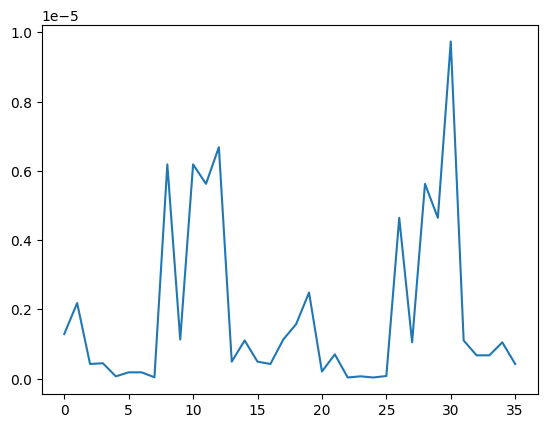

In [16]:
plt.plot(s_all)

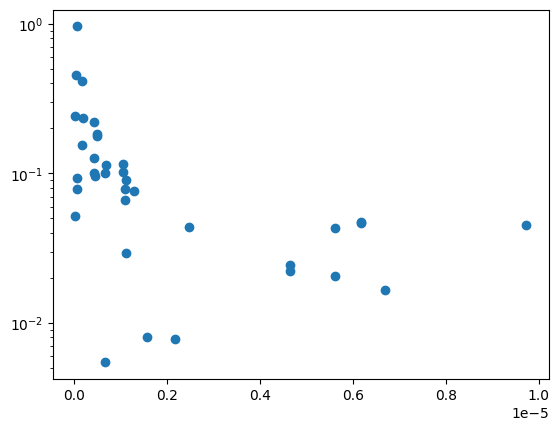

In [15]:
plt.scatter(s_all, res_all)
plt.yscale('log')

# plt.scatter(idx_all, res_all)
# plt.yscale('log')

In [ ]:
v1

tensor([[[ 1.7907e-01],
         [ 1.9290e-01],
         [ 6.3966e-02],
         ...,
         [ 9.8787e-02],
         [-1.6164e-03],
         [-4.2757e-01]],

        [[ 1.0256e-01],
         [ 3.8460e-01],
         [ 9.5039e-02],
         ...,
         [-1.0412e-02],
         [ 1.5362e-02],
         [-1.9004e-02]],

        [[-2.5940e-03],
         [ 1.2918e+00],
         [ 2.7341e-02],
         ...,
         [-4.8268e-03],
         [-7.2511e-02],
         [ 4.1065e-03]],

        [[-1.5051e-02],
         [-4.8234e+00],
         [ 3.9911e-01],
         ...,
         [ 1.3587e+00],
         [-3.1493e-02],
         [ 1.0623e+00]],

        [[ 7.9484e-01],
         [-1.6201e-01],
         [ 7.2368e+00],
         ...,
         [ 6.5900e+00],
         [ 3.8332e+00],
         [-2.7908e-02]]], device='cuda:0')

In [14]:
import matplotlib.pyplot as plt


In [6]:
%matplotlib qt


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

rs = res[0][idx, :-250].detach().cpu().__abs__()
# rs[rs > 500] = 500

ax.scatter(*x[idx, :-250].cpu().T, s=20, c=rs)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()

IndexError: index 1 is out of bounds for dimension 0 with size 1

In [ ]:
abs(res[0]).max()

tensor(1203.1420, device='cuda:0', grad_fn=<MaxBackward1>)

In [ ]:
idx=7

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')


ax.scatter(*x[idx, :-250].cpu().T, s=20, c=((v1[idx, :, 0].detach().cpu() ** 2 + v2[idx, :, 0].detach().cpu() ** 2 + v3[idx, :, 0].detach().cpu() ** 2) ** 0.5).detach().cpu())

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()

In [ ]:
((v1[idx, :, 0].detach().cpu() ** 2 + v2[idx, :, 0].detach().cpu() ** 2 + v3[idx, :, 0].detach().cpu() ** 2) ** 0.5).detach().cpu().max()

tensor(14.6280)

In [ ]:
idx = 12
# 2 5 10

In [ ]:
norm_in[:, 0, :]

tensor([[0.3762, 0.8621, 0.3395]], device='cuda:0')

In [ ]:
-0.3732, -0.7506, -0.5453

(-0.3732, -0.7506, -0.5453)

In [ ]:
norm_in

tensor([[[ 0.3762,  0.8621,  0.3395],
         [ 0.3762,  0.8621,  0.3395],
         [ 0.3762,  0.8621,  0.3395],
         ...,
         [ 0.3762,  0.8621,  0.3395],
         [ 0.3762,  0.8621,  0.3395],
         [ 0.3762,  0.8621,  0.3395]],

        [[-0.0456, -0.0761, -0.9961],
         [-0.0456, -0.0761, -0.9961],
         [-0.0456, -0.0761, -0.9961],
         ...,
         [-0.0456, -0.0761, -0.9961],
         [-0.0456, -0.0761, -0.9961],
         [-0.0456, -0.0761, -0.9961]]], device='cuda:0')

In [9]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(196808001)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

pos = x[idx, :-250].cpu()
u = v1[idx, :, 0].detach().cpu()
v = v2[idx, :, 0].detach().cpu()
w = v3[idx, :, 0].detach().cpu()

# pos = x[idx, 750:850].cpu()
# u = v1[idx, 750:850, 0].detach().cpu()
# v = v2[idx, 750:850, 0].detach().cpu()
# w = v3[idx, 750:850, 0].detach().cpu()

# pos = x[idx, 750:850].cpu()
# u = (1 * phi_pred[idx, :-250, 1].detach().cpu() + phi_pred[idx, :-250, 0].detach().cpu())[750:850] * (-0.4576)
# v = (1 * phi_pred[idx, :-250, 1].detach().cpu() + phi_pred[idx, :-250, 0].detach().cpu())[750:850] * (-0.1545)
# w = (1 * phi_pred[idx, :-250, 1].detach().cpu() + phi_pred[idx, :-250, 0].detach().cpu())[750:850] * (-0.8757)

speed = (u ** 2 + v ** 2 + w ** 2) ** 0.5

# ax.scatter(*pos.T, s=20, c=speed)

# Subsample to avoid overcrowding
step = 1
pos_q = pos[::step]
u_q, v_q, w_q = u[::step], v[::step], w[::step]

scale = float(pos.abs().max()) * 0.08
ax.quiver(
    pos_q[:, 0], pos_q[:, 1], pos_q[:, 2],
    u_q, v_q, w_q,
    length=scale,
    color='r', alpha=0.8, linewidth=0.7, arrow_length_ratio=0.7,
)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# ax.scatter(*x[idx, :-250].cpu().T, s=5, c=phi_pred[idx, :-250, 0].detach().cpu())

# ax.set_xlabel('X Label')
# ax.set_ylabel('Y Label')
# ax.set_zlabel('Z Label')
# # plt.colorbar()
# plt.show()


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(*x[idx, 750:950].cpu().T, s=20, c=(1 * phi[idx, :-250, 1].detach().cpu() + phi[idx, :-250, 0].detach().cpu())[750:950])

# sc = ax.scatter(*x[idx, 750:950].cpu().T, s=20, c=((v1[idx, :, 0].detach().cpu() ** 2 + v2[idx, :, 0].detach().cpu() ** 2 + v3[idx, :, 0].detach().cpu() ** 2) ** 0.5).detach().cpu()[750:950])

ax.set_axis_off()
plt.colorbar(sc, ax=ax)
plt.show()

In [9]:
%matplotlib qt

In [10]:
idx = 0

import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*x[idx, -250:].cpu().T, s=10, c=(phi[idx, -250:, 0]).detach().cpu())
# ax.scatter(*x[idx, 500:750].cpu().T, s=10, c=(phi[idx, 500:750, 0]).detach().cpu())
# ax.scatter(*(x[idx, 750:950].cpu() + phi[idx, 750:950, 0].detach().unsqueeze(1).cpu() * norm_in[0][:200].cpu()).T , s=10, c=phi[idx, 750:950, 0].detach().cpu())

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()


# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==0].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==1].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==3].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==2].cpu().T, s=10)

ax.set_axis_off()
# plt.colorbar(sc, ax=ax)
plt.show()

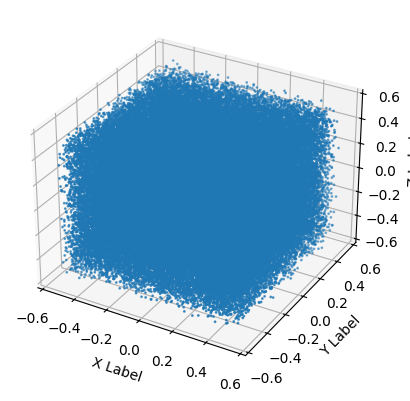

In [22]:
idx = 6

import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*(dataset.data[idx]['x_dict']['outerior'] + (torch.rand(*dataset.data[idx]['x_dict']['outerior'].shape) - 0.5) * 2 * 0.05).T, s=1)
# ax.scatter(*(x[idx, 750:950].cpu() + phi[idx, 750:950, 0].detach().unsqueeze(1).cpu() * norm_in[0][:200].cpu()).T , s=10, c=phi[idx, 750:950, 0].detach().cpu())

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()


# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==0].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==1].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==3].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==2].cpu().T, s=10)

ax.set_axis_off()
# plt.colorbar(sc, ax=ax)
plt.show()

In [14]:
dataset.data[0]['x_dict']['outerior'].shape

torch.Size([249103, 3])

In [40]:
(phi[idx, :750, 0] - phi_pred[idx, :750, 0]).mean()

tensor(0.0151, device='cuda:0')

tensor([[-0.0424, -0.0708, -0.9258],
        [-0.0424, -0.0708, -0.9266],
        [-0.0426, -0.0711, -0.9304],
        [-0.0441, -0.0737, -0.9641],
        [-0.0326, -0.0545, -0.7127],
        [-0.0329, -0.0548, -0.7175],
        [-0.0409, -0.0682, -0.8928],
        [-0.0286, -0.0478, -0.6253],
        [-0.0381, -0.0637, -0.8331],
        [-0.0419, -0.0700, -0.9158],
        [-0.0370, -0.0617, -0.8069],
        [-0.0324, -0.0541, -0.7073],
        [-0.0455, -0.0760, -0.9938],
        [-0.0447, -0.0746, -0.9764],
        [-0.0416, -0.0695, -0.9095],
        [-0.0421, -0.0702, -0.9187],
        [-0.0389, -0.0649, -0.8487],
        [-0.0381, -0.0636, -0.8315],
        [-0.0303, -0.0506, -0.6619],
        [-0.0453, -0.0757, -0.9901],
        [-0.0321, -0.0536, -0.7007],
        [-0.0446, -0.0744, -0.9737],
        [-0.0387, -0.0646, -0.8451],
        [-0.0454, -0.0758, -0.9921],
        [-0.0444, -0.0742, -0.9706],
        [-0.0435, -0.0726, -0.9499],
        [-0.0321, -0.0536, -0.7016],
 

In [58]:
norm_in[0][:200] * phi[idx, 750:950, 0].detach().cpu()

RuntimeError: The size of tensor a (3) must match the size of tensor b (200) at non-singleton dimension 1

In [31]:
phi[idx, :500, 0].detach().cpu().shape

torch.Size([500])

In [34]:
phi_pred[idx, :500, 0].min()

tensor(-0.0057, device='cuda:0')

In [1]:
a = 1
b = 2

def fcn():
    global a, b
    a = 3
    b = 4

In [2]:
fcn()

In [4]:
b

4

In [27]:
idx = 5+18

import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*x[idx, 750:850].cpu().T, s=50, c=phi[idx, 750:850, 0].detach().cpu())

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()


# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==0].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==1].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==3].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==2].cpu().T, s=10)

ax.set_axis_off()
# plt.colorbar(sc, ax=ax)
plt.show()

IndexError: index 23 is out of bounds for dimension 0 with size 1

In [12]:
%matplotlib qt

In [14]:

import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*dataset_train.data[0]['x_dict']['interior'][::10].cpu().T, s=0.1)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()


In [ ]:
dataset_train

In [41]:
len(dataset.data[0]['x_dict']['interior'])

50000

tensor([[ 0.0519,  0.0042,  0.3127],
        [ 0.0233,  0.1014,  0.2389],
        [-0.0857, -0.1599, -0.3332],
        ...,
        [ 0.0697,  0.0198,  0.1545],
        [-0.0241,  0.1641,  0.2785],
        [ 0.1133, -0.0963, -0.1986]])

In [ ]:
out.shape

torch.Size([2, 6])

In [18]:
idx = 0

import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*x[idx, :-250].cpu().T, s=5, c=phi_pred[idx, :-250, 1].detach().cpu())

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()


# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==0].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==1].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==3].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==2].cpu().T, s=10)

ax.set_axis_off()
# plt.colorbar(sc, ax=ax)
plt.show()

In [ ]:
x_label.shape

torch.Size([18, 1200])

In [ ]:
idx=4

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*x[idx, :].cpu().T, s=5, c=phi_pred[idx, :, 0].detach().cpu())

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()

In [ ]:
plt.plot(phi[idx, :, 0].cpu())
plt.plot(phi_pred[idx, :, 0].detach().cpu())
plt.plot(x_label[idx, :].detach().cpu())

In [ ]:
abs(phi[idx, :, 0].cpu() - phi_pred[idx, :, 0].detach().cpu()).mean()

tensor(2.7198)

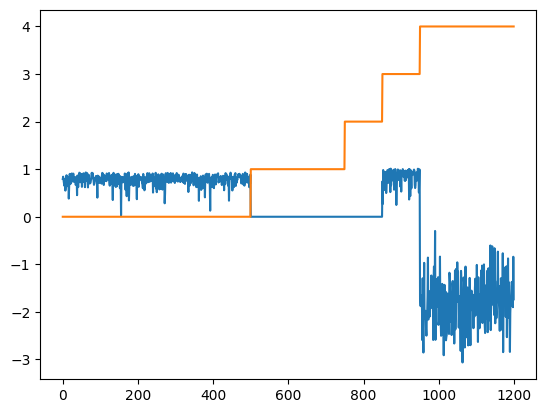

In [16]:
plt.plot(phi[5, :, 1].cpu())
# plt.plot(phi_pred[idx, :, 1].detach().cpu())
plt.plot(x_label[idx, :].detach().cpu())

In [ ]:
plt.plot(v1[idx, :, 0].detach().cpu())
plt.plot(x_label[idx, :].detach().cpu())

In [ ]:
plt.plot(phi[idx, :, 0].cpu())
plt.plot(((v1[idx, :, 0].detach().cpu() ** 2 + v2[idx, :, 0].detach().cpu() ** 2 + v3[idx, :, 0].detach().cpu() ** 2) ** 0.5) / ((1 / v_mean[idx, :_BND_END, 0].detach().cpu())*(Q / s[idx, :_BND_END, 0].detach().cpu())))
plt.plot(x_label[idx, :].detach().cpu())

In [ ]:
plt.plot(phi[idx, :, 0].cpu())
a = ((1 / v_mean[idx, :_BND_END, 0].detach().cpu())*(Q / s[idx, :_BND_END, 0].detach().cpu()))
plt.plot(((v1[idx, :, 0].detach().cpu() / a / 3 / norm_in[idx, :-250, 0].cpu() + v2[idx, :, 0].detach().cpu() / a / 3 / norm_in[idx, :-250, 1].cpu() + v3[idx, :, 0].detach().cpu() / a / 3 / norm_in[idx, :-250, 2].cpu())))
plt.plot(x_label[idx, :].detach().cpu())

In [ ]:
plt.plot(phi[idx, :, 0].cpu())
plt.plot(p[idx, :, 0].detach().cpu() / 2500)
plt.plot(x_label[idx, :].detach().cpu())

In [ ]:
with open('history_pinn.json', 'r') as fp:
    history = json.load(fp)

In [ ]:
plt.plot(history['res_1'])
plt.yscale('log')

In [ ]:
import torch
from torch import Tensor


def point_to_triangle_distance(points: Tensor, triangles: Tensor) -> Tensor:
    """
    Вычисляет расстояние от точек до треугольников.

    Args:
        points:    (B, 3) — батч точек
        triangles: (B, 3, 3) — батч треугольников (три вершины)

    Returns:
        distances: (B,) — расстояния от каждой точки до соответствующего треугольника
    """
    # Вершины треугольника
    a = triangles[:, 0, :]  # (B, 3)
    b = triangles[:, 1, :]  # (B, 3)
    c = triangles[:, 2, :]  # (B, 3)

    # Рёбра
    ab = b - a
    ac = c - a
    ap = points - a

    # Проекция точки в барицентрические координаты
    d1 = (ab * ap).sum(dim=-1)
    d2 = (ac * ap).sum(dim=-1)

    # Регион 1: ближайшая точка — вершина A
    mask_a = (d1 <= 0) & (d2 <= 0)

    bp = points - b
    d3 = (ab * bp).sum(dim=-1)
    d4 = (ac * bp).sum(dim=-1)

    # Регион 2: ближайшая точка — вершина B
    mask_b = (d3 >= 0) & (d4 <= d3)

    cp = points - c
    d5 = (ab * cp).sum(dim=-1)
    d6 = (ac * cp).sum(dim=-1)

    # Регион 3: ближайшая точка — вершина C
    mask_c = (d6 >= 0) & (d5 <= d6)

    # Регион 4: ближайшая точка на ребре AB
    vc = d1 * d4 - d3 * d2
    t_ab = d1 / (d1 - d3)
    mask_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)

    # Регион 5: ближайшая точка на ребре AC
    vb = d5 * d2 - d1 * d6
    t_ac = d2 / (d2 - d6)
    mask_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)

    # Регион 6: ближайшая точка на ребре BC
    va = d3 * d6 - d5 * d4
    t_bc = (d4 - d3) / ((d4 - d3) + (d5 - d6))
    mask_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)

    # Внутри треугольника
    denom = 1.0 / (va + vb + vc).clamp(min=1e-10)
    v = vb * denom
    w = vc * denom

    # Ближайшие точки для каждого региона
    B = points.shape[0]
    closest = torch.zeros_like(points)

    closest[mask_a]  = a[mask_a]
    closest[mask_b]  = b[mask_b]
    closest[mask_c]  = c[mask_c]
    closest[mask_ab] = a[mask_ab] + t_ab[mask_ab, None] * ab[mask_ab]
    closest[mask_ac] = a[mask_ac] + t_ac[mask_ac, None] * ac[mask_ac]
    closest[mask_bc] = b[mask_bc] + t_bc[mask_bc, None] * (c[mask_bc] - b[mask_bc])

    # Все остальные точки — внутри треугольника
    mask_inner = ~(mask_a | mask_b | mask_c | mask_ab | mask_ac | mask_bc)
    closest[mask_inner] = (
        a[mask_inner]
        + v[mask_inner, None] * ab[mask_inner]
        + w[mask_inner, None] * ac[mask_inner]
    )

    distances = (points - closest).norm(dim=-1)
    return distances

In [ ]:
import time

t_start = time.time()

# Один треугольник, несколько точек
triangle = torch.tensor([
    [0., 0., 0.],
    [1., 0., 0.],
    [0., 1., 0.],
])

points = torch.tensor([
    [0.25, 0.25, 0.0],  # внутри — дистанция 0
    [0.50, 0.50, 1.0],  # над серединой гипотенузы
    [2.00, 0.00, 0.0],  # за пределами, у продолжения AB
])

points = torch.randn(1000000, 3)

# Размножаем треугольник по батчу
triangles = triangle.unsqueeze(0).expand(len(points), -1, -1)

dists = point_to_triangle_distance(points.to('cuda'), triangles.to('cuda'))
print(dists)  # tensor([0.0000, 0.7071, 1.0000])

print(time.time() - t_start)


tensor([1.4311, 0.8907, 1.1425,  ..., 0.3751, 1.7480, 0.9565], device='cuda:0')
0.03321337699890137


In [ ]:
points.shape

torch.Size([3, 3])

In [ ]:
import torch
from torch import Tensor


def point_to_triangles_distance(points: Tensor, triangles: Tensor) -> Tensor:
    """
    Расстояние от каждой точки до каждого треугольника (fully vectorized).

    Args:
        points:    (M, 3)    — M точек
        triangles: (N, 3, 3) — N треугольников, каждый задан тремя вершинами

    Returns:
        distances: (M, N)    — расстояние от точки i до треугольника j
    """
    # (M, N, 3) через broadcast
    p = points[:, None, :]       # (M, 1, 3)
    a = triangles[None, :, 0, :] # (1, N, 3)
    b = triangles[None, :, 1, :] # (1, N, 3)
    c = triangles[None, :, 2, :] # (1, N, 3)

    ab = b - a  # (1, N, 3)
    ac = c - a  # (1, N, 3)
    ap = p - a  # (M, N, 3)

    def dot(x, y):
        return (x * y).sum(dim=-1)  # (M, N)

    d1 = dot(ab, ap)
    d2 = dot(ac, ap)

    bp = p - b
    d3 = dot(ab, bp)
    d4 = dot(ac, bp)

    cp = p - c
    d5 = dot(ab, cp)
    d6 = dot(ac, cp)

    va = d3 * d6 - d5 * d4
    vb = d5 * d2 - d1 * d6
    vc = d1 * d4 - d3 * d2

    # --- Маски регионов ---
    mask_a  = (d1 <= 0) & (d2 <= 0)
    mask_b  = (d3 >= 0) & (d4 <= d3)
    mask_c  = (d6 >= 0) & (d5 <= d6)
    mask_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
    mask_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
    mask_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)

    # Параметры проекций на рёбра
    t_ab = (d1 / (d1 - d3).clamp(min=1e-10)).clamp(0, 1)
    t_ac = (d2 / (d2 - d6).clamp(min=1e-10)).clamp(0, 1)
    t_bc = ((d4 - d3) / ((d4 - d3) + (d5 - d6)).clamp(min=1e-10)).clamp(0, 1)

    # Барицентрические координаты для внутренней области
    denom = (va + vb + vc).clamp(min=1e-10)
    v = vb / denom
    w = vc / denom

    # --- Собираем ближайшую точку ---
    # Начинаем с проекции на плоскость (внутренняя область)
    closest = a + v[..., None] * ab + w[..., None] * ac  # (M, N, 3)

    # Рёбра (порядок важен — перезаписываем от общего к частному)
    closest = torch.where(mask_bc[..., None], b + t_bc[..., None] * (c - b), closest)
    closest = torch.where(mask_ac[..., None], a + t_ac[..., None] * ac,      closest)
    closest = torch.where(mask_ab[..., None], a + t_ab[..., None] * ab,      closest)

    # Вершины
    closest = torch.where(mask_c[..., None], c, closest)
    closest = torch.where(mask_b[..., None], b, closest)
    closest = torch.where(mask_a[..., None], a, closest)

    return (p - closest).norm(dim=-1)  # (M, N)

In [ ]:
def point_to_triangles_distance_chunked(
    points: Tensor,
    triangles: Tensor,
    chunk_size: int = 1024,
) -> Tensor:
    """Экономит память: обрабатывает точки чанками."""
    return torch.cat([
        point_to_triangles_distance(chunk, triangles)
        for chunk in points.split(chunk_size)
    ], dim=0)

In [ ]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

M, N = 1000000, 200
points    = torch.randn(M, 3, device=device)
triangles = torch.randn(N, 3, 3, device=device)

# Прогрев
_ = point_to_triangles_distance(points[:10], triangles[:200])

torch.cuda.synchronize() if device.type == "cuda" else None
t0 = time.perf_counter()
dists = point_to_triangles_distance(points, triangles)
torch.cuda.synchronize() if device.type == "cuda" else None
print(f"Shape: {dists.shape}")           # (10000, 50000)
print(f"Time:  {time.perf_counter()-t0:.3f}s")

Shape: torch.Size([1000000, 200])
Time:  13.278s


In [ ]:
0.586 / 100

0.00586

In [ ]:
import torch
from torch import Tensor


def point_to_triangles_distance(
    points: Tensor,      # (P, 3)
    triangles: Tensor,   # (T, 3, 3)
) -> Tensor:
    """
    Расстояние от каждой точки до каждого треугольника.

    Args:
        points:    (P, 3)
        triangles: (T, 3, 3)

    Returns:
        distances: (P, T) — dist[i, j] = расстояние от points[i] до triangles[j]
    """
    P = points.shape[0]
    T = triangles.shape[0]

    # Broadcast: points (P,1,3), triangles (1,T,3)
    a = triangles[:, 0, :].unsqueeze(0)   # (1, T, 3)
    b = triangles[:, 1, :].unsqueeze(0)   # (1, T, 3)
    c = triangles[:, 2, :].unsqueeze(0)   # (1, T, 3)
    p = points.unsqueeze(1)               # (P, 1, 3)

    ab = b - a   # (1, T, 3)
    ac = c - a   # (1, T, 3)
    ap = p - a   # (P, T, 3)

    d1 = (ab * ap).sum(-1)   # (P, T)
    d2 = (ac * ap).sum(-1)   # (P, T)

    bp = p - b
    d3 = (ab * bp).sum(-1)
    d4 = (ac * bp).sum(-1)

    cp = p - c
    d5 = (ab * cp).sum(-1)
    d6 = (ac * cp).sum(-1)

    va = d3 * d6 - d5 * d4
    vb = d5 * d2 - d1 * d6
    vc = d1 * d4 - d3 * d2

    # Маски регионов
    mask_a  = (d1 <= 0) & (d2 <= 0)
    mask_b  = (d3 >= 0) & (d4 <= d3)
    mask_c  = (d6 >= 0) & (d5 <= d6)
    mask_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
    mask_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
    mask_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)

    # Параметры проекций на рёбра
    t_ab = (d1 / (d1 - d3).clamp(min=1e-10)).clamp(0, 1)
    t_ac = (d2 / (d2 - d6).clamp(min=1e-10)).clamp(0, 1)
    t_bc = ((d4 - d3) / ((d4 - d3) + (d5 - d6)).clamp(min=1e-10)).clamp(0, 1)

    # Барицентрические координаты для внутренней точки
    denom = (va + vb + vc).clamp(min=1e-10)
    v = vb / denom
    w = vc / denom

    # Ближайшие точки: (P, T, 3)
    closest = (
        # Внутри (дефолт)
        a + v.unsqueeze(-1) * ab + w.unsqueeze(-1) * ac
    )
    closest = torch.where(mask_bc.unsqueeze(-1), b + t_bc.unsqueeze(-1) * (c - b), closest)
    closest = torch.where(mask_ac.unsqueeze(-1), a + t_ac.unsqueeze(-1) * ac,       closest)
    closest = torch.where(mask_ab.unsqueeze(-1), a + t_ab.unsqueeze(-1) * ab,       closest)
    closest = torch.where(mask_c.unsqueeze(-1),  c.expand(P, T, 3),                 closest)
    closest = torch.where(mask_b.unsqueeze(-1),  b.expand(P, T, 3),                 closest)
    closest = torch.where(mask_a.unsqueeze(-1),  a.expand(P, T, 3),                 closest)

    dist = (p - closest).norm(dim=-1)   # (P, T)
    return dist


def point_to_nearest_triangle_distance(
    points: Tensor,      # (P, 3)
    triangles: Tensor,   # (T, 3, 3)
    chunk_size: int = 512,
) -> tuple[Tensor, Tensor]:
    """
    Расстояние от каждой точки до БЛИЖАЙШЕГО треугольника.
    Чанкование по точкам — контроль пика памяти при P*T >> RAM.

    Returns:
        min_dist:  (P,)  — минимальное расстояние
        min_idx:   (P,)  — индекс ближайшего треугольника
    """
    results_dist = []
    results_idx  = []

    for start in tqdm(range(0, points.shape[0], chunk_size)):
        chunk = points[start : start + chunk_size]         # (C, 3)
        d = point_to_triangles_distance(chunk, triangles)  # (C, T)
        min_d, min_i = d.min(dim=-1)
        results_dist.append(min_d)
        results_idx.append(min_i)

    return torch.cat(results_dist), torch.cat(results_idx)

In [ ]:
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

P, T = 1000000, 30000
points    = torch.randn(P, 3, device=device)
triangles = torch.randn(T, 3, 3, device=device)

min_dist, min_idx = point_to_nearest_triangle_distance(
    points, triangles, chunk_size=500
)
print(min_dist.shape)   # (10000,)
print(min_idx.shape)    # (10000,)

  4%|▎         | 70/2000 [00:04<02:00, 15.98it/s]


KeyboardInterrupt: 

In [4]:
import torch
from torch import Tensor


def point_to_triangles_distance(
    points: Tensor,      # (P, 3)
    triangles: Tensor,   # (T, 3, 3)
) -> Tensor:
    """
    Расстояние от каждой точки до каждого треугольника.

    Returns:
        distances: (P, T)
    """
    P = points.shape[0]
    T = triangles.shape[0]

    a = triangles[:, 0, :].unsqueeze(0)   # (1, T, 3)
    b = triangles[:, 1, :].unsqueeze(0)
    c = triangles[:, 2, :].unsqueeze(0)
    p = points.unsqueeze(1)               # (P, 1, 3)

    ab = b - a
    ac = c - a
    ap = p - a

    d1 = (ab * ap).sum(-1)
    d2 = (ac * ap).sum(-1)

    bp = p - b
    d3 = (ab * bp).sum(-1)
    d4 = (ac * bp).sum(-1)

    cp = p - c
    d5 = (ab * cp).sum(-1)
    d6 = (ac * cp).sum(-1)

    va = d3 * d6 - d5 * d4
    vb = d5 * d2 - d1 * d6
    vc = d1 * d4 - d3 * d2

    mask_a  = (d1 <= 0) & (d2 <= 0)
    mask_b  = (d3 >= 0) & (d4 <= d3)
    mask_c  = (d6 >= 0) & (d5 <= d6)
    mask_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
    mask_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
    mask_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)

    t_ab = (d1 / (d1 - d3).clamp(min=1e-10)).clamp(0, 1)
    t_ac = (d2 / (d2 - d6).clamp(min=1e-10)).clamp(0, 1)
    t_bc = ((d4 - d3) / ((d4 - d3) + (d5 - d6)).clamp(min=1e-10)).clamp(0, 1)

    denom = (va + vb + vc).clamp(min=1e-10)
    v = vb / denom
    w = vc / denom

    closest = a + v.unsqueeze(-1) * ab + w.unsqueeze(-1) * ac
    closest = torch.where(mask_bc.unsqueeze(-1), b + t_bc.unsqueeze(-1) * (c - b), closest)
    closest = torch.where(mask_ac.unsqueeze(-1), a + t_ac.unsqueeze(-1) * ac,       closest)
    closest = torch.where(mask_ab.unsqueeze(-1), a + t_ab.unsqueeze(-1) * ab,       closest)
    closest = torch.where(mask_c.unsqueeze(-1),  c.expand(P, T, 3),                 closest)
    closest = torch.where(mask_b.unsqueeze(-1),  b.expand(P, T, 3),                 closest)
    closest = torch.where(mask_a.unsqueeze(-1),  a.expand(P, T, 3),                 closest)

    return (p - closest).norm(dim=-1)   # (P, T)


def point_to_nearest_triangle_distance(
    points: Tensor,             # (P, 3)
    triangles: Tensor,          # (T, 3, 3)
    point_chunk_size: int | None = 512,
    triangle_chunk_size: int | None = None,
) -> tuple[Tensor, Tensor]:
    """
    Расстояние от каждой точки до ближайшего треугольника.

    Args:
        points:              (P, 3)
        triangles:           (T, 3, 3)
        point_chunk_size:    чанк по точкам    (None = без разбивки)
        triangle_chunk_size: чанк по треугольникам (None = без разбивки)

    Returns:
        min_dist: (P,)  — минимальное расстояние до ближайшего треугольника
        min_idx:  (P,)  — индекс ближайшего треугольника
    """
    P = points.shape[0]
    T = triangles.shape[0]

    p_chunk  = point_chunk_size    or P
    t_chunk  = triangle_chunk_size or T

    all_dist = []
    all_idx  = []

    for p_start in tqdm(range(0, P, p_chunk)):
        p_end   = min(p_start + p_chunk, P)
        p_batch = points[p_start:p_end]          # (Cp, 3)

        # Аккумулируем минимум по чанкам треугольников
        best_dist = None
        best_idx  = None

        for t_start in range(0, T, t_chunk):
            t_end   = min(t_start + t_chunk, T)
            t_batch = triangles[t_start:t_end]   # (Ct, 3, 3)

            d = point_to_triangles_distance(p_batch, t_batch)  # (Cp, Ct)

            chunk_min_dist, chunk_min_idx = d.min(dim=-1)      # (Cp,)
            chunk_min_idx = chunk_min_idx + t_start            # глобальный индекс

            if best_dist is None:
                best_dist = chunk_min_dist
                best_idx  = chunk_min_idx
            else:
                improved  = chunk_min_dist < best_dist
                best_dist = torch.where(improved, chunk_min_dist, best_dist)
                best_idx  = torch.where(improved, chunk_min_idx,  best_idx)

        all_dist.append(best_dist)
        all_idx.append(best_idx)

    return torch.cat(all_dist), torch.cat(all_idx)

In [2]:
from tqdm import tqdm

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

points    = torch.randn(100000, 3, device=device).to(torch.float16)
triangles = torch.randn(65000, 3, 3, device=device).to(torch.float16)

# # # Только по точкам
# dist, idx = point_to_nearest_triangle_distance(points, triangles,
#     point_chunk_size=200)

# # Только по треугольникам
# dist, idx = point_to_nearest_triangle_distance(points, triangles,
#     point_chunk_size=None, triangle_chunk_size=1)

# Оба направления — минимальный пик памяти
dist, idx = point_to_nearest_triangle_distance(points, triangles,
    point_chunk_size=200, triangle_chunk_size=10000)

100%|██████████| 500/500 [00:09<00:00, 53.72it/s]


In [11]:
import numpy as np

import os
from stl import mesh

lengths = []
path = "New\SimVascDataset"

for dir in os.listdir(path):
    for file in os.listdir(os.path.join(path, dir)):
        if (file.count('_') == 1) and (file.split('_')[-1] != '-1.stl') and ('.stl' in file):
            if file.replace('.stl', '.pt') in os.listdir(os.path.join(path, dir)):
                closed_mesh = mesh.Mesh.from_file(os.path.join(path, dir, file))
                # print(len(closed_mesh.points))
                lengths.append(len(closed_mesh.points))

np.mean(lengths)

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\chest\AppData\Local\Temp\ipykernel_33308\2618510538.py:7: SyntaxWarning: invalid escape sequence '\S'
  path = "New\SimVascDataset"


np.float64(13470.373493975903)

In [54]:
a = closed_mesh.points.reshape(-1, 3, 3)

In [16]:
a[0][1]

array([-2.7871368, -3.4554422, 15.169011 ], dtype=float32)

In [ ]:
os.path.join(path, dir, file)

'New\\SimVascDataset\\0018_H_AO_COA\\1_1.stl'

In [5]:
import torch
from torch import Tensor


def point_to_triangle_distance(
    points: Tensor,    # (P, 3)
    triangle: Tensor,  # (3, 3)
    point_chunk_size: int = 1_000_000,
) -> Tensor:
    """
    Расстояние от каждой точки до одного треугольника.

    Args:
        points:          (P, 3)
        triangle:        (3, 3) — три вершины треугольника
        point_chunk_size: размер чанка по точкам (default: 1_000_000)

    Returns:
        dist: (P,)
    """
    P = points.shape[0]

    a  = triangle[0]
    b  = triangle[1]
    c  = triangle[2]
    ab = b - a
    ac = c - a
    bc = c - b

    dist = torch.empty(P, device=points.device, dtype=points.dtype)

    for p_start in range(0, P, point_chunk_size):
        p_end = min(p_start + point_chunk_size, P)
        p     = points[p_start:p_end]

        ap = p - a
        bp = p - b
        cp = p - c

        d1 = (ab * ap).sum(-1)
        d2 = (ac * ap).sum(-1)
        d3 = (ab * bp).sum(-1)
        d4 = (ac * bp).sum(-1)
        d5 = (ab * cp).sum(-1)
        d6 = (ac * cp).sum(-1)

        va = d3 * d6 - d5 * d4
        vb = d5 * d2 - d1 * d6
        vc = d1 * d4 - d3 * d2

        mask_a  = (d1 <= 0) & (d2 <= 0)
        mask_b  = (d3 >= 0) & (d4 <= d3)
        mask_c  = (d6 >= 0) & (d5 <= d6)
        mask_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
        mask_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
        mask_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)

        t_ab = (d1 / (d1 - d3).clamp(min=1e-10)).clamp(0.0, 1.0)
        t_ac = (d2 / (d2 - d6).clamp(min=1e-10)).clamp(0.0, 1.0)
        t_bc = ((d4 - d3) / ((d4 - d3) + (d5 - d6)).clamp(min=1e-10)).clamp(0.0, 1.0)

        denom = (va + vb + vc).clamp(min=1e-10)
        v = vb / denom
        w = vc / denom

        closest = a + v.unsqueeze(-1) * ab + w.unsqueeze(-1) * ac
        closest[mask_bc] = b + t_bc[mask_bc].unsqueeze(-1) * bc
        closest[mask_ac] = a + t_ac[mask_ac].unsqueeze(-1) * ac
        closest[mask_ab] = a + t_ab[mask_ab].unsqueeze(-1) * ab
        closest[mask_c]  = c
        closest[mask_b]  = b
        closest[mask_a]  = a

        dist[p_start:p_end] = (p - closest).norm(dim=-1)

        del ap, bp, cp, d1, d2, d3, d4, d5, d6
        del va, vb, vc, mask_a, mask_b, mask_c
        del mask_ab, mask_ac, mask_bc
        del t_ab, t_ac, t_bc, denom, v, w, closest

    return dist

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

points    = torch.randn(1000000, 3, device=device)
triangles = torch.randn(12500, 3, 3, device=device)

In [6]:
from tqdm import tqdm

In [11]:
for i in tqdm(range(12000)):

    point_to_triangle_distance(
        points,
        triangles[0]
    )

100%|██████████| 12000/12000 [00:34<00:00, 347.01it/s]


In [45]:
torch.cuda.empty_cache()

In [302]:
import torch
from torch import Tensor


def point_to_triangles_distance(
    points: Tensor,               # (P, 3)
    triangles: Tensor,            # (T, 3, 3)
    point_chunk_size: int | None = 200,
    triangle_chunk_size: int | None = 10000,
) -> Tensor:
    """
    Returns:
        sum_dist: (P,) — сумма расстояний от каждой точки до всех треугольников
    """
    P = points.shape[0]
    T = triangles.shape[0]

    p_chunk = point_chunk_size    or P
    t_chunk = triangle_chunk_size or T

    sum_dist = torch.zeros(P, dtype=points.dtype, device=points.device)

    for p_start in range(0, P, p_chunk):
        p_end = min(p_start + p_chunk, P)
        p = points[p_start:p_end].unsqueeze(1)   # (Cp, 1, 3)

        for t_start in range(0, T, t_chunk):
            t_end = min(t_start + t_chunk, T)
            tri   = triangles[t_start:t_end]      # (Ct, 3, 3)

            a  = tri[:, 0].unsqueeze(0)
            b  = tri[:, 1].unsqueeze(0)
            c  = tri[:, 2].unsqueeze(0)
            ab = b - a
            ac = c - a
            ap = p - a

            d1 = (ab * ap).sum(-1)
            d2 = (ac * ap).sum(-1)
            bp = p - b
            d3 = (ab * bp).sum(-1)
            d4 = (ac * bp).sum(-1)
            cp = p - c
            d5 = (ab * cp).sum(-1)
            d6 = (ac * cp).sum(-1)

            va = d3 * d6 - d5 * d4
            vb = d5 * d2 - d1 * d6
            vc = d1 * d4 - d3 * d2

            mask_a  = (d1 <= 0) & (d2 <= 0)
            mask_b  = (d3 >= 0) & (d4 <= d3)
            mask_c  = (d6 >= 0) & (d5 <= d6)
            mask_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
            mask_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
            mask_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)

            t_ab = (d1 / (d1 - d3).clamp(min=1e-10)).clamp(0.0, 1.0)
            t_ac = (d2 / (d2 - d6).clamp(min=1e-10)).clamp(0.0, 1.0)
            t_bc = ((d4 - d3) / ((d4 - d3) + (d5 - d6)).clamp(min=1e-10)).clamp(0.0, 1.0)

            denom   = (va + vb + vc).clamp(min=1e-10)
            closest = a + (vb / denom).unsqueeze(-1) * ab + (vc / denom).unsqueeze(-1) * ac

            Cp = p_end - p_start
            Ct = t_end - t_start
            closest = torch.where(mask_bc.unsqueeze(-1), b + t_bc.unsqueeze(-1) * (c - b), closest)
            closest = torch.where(mask_ac.unsqueeze(-1), a + t_ac.unsqueeze(-1) * ac,       closest)
            closest = torch.where(mask_ab.unsqueeze(-1), a + t_ab.unsqueeze(-1) * ab,       closest)
            closest = torch.where(mask_c.unsqueeze(-1),  c.expand(Cp, Ct, 3),               closest)
            closest = torch.where(mask_b.unsqueeze(-1),  b.expand(Cp, Ct, 3),               closest)
            closest = torch.where(mask_a.unsqueeze(-1),  a.expand(Cp, Ct, 3),               closest)

            # Суммируем по треугольникам прямо здесь — (Cp,)
            sum_dist[p_start:p_end] += (1.0 / (p - closest).norm(dim=-1).pow(3).clamp(min=1e-10)).sum(dim=-1)

            del a, b, c, ab, ac, ap, bp, cp
            del d1, d2, d3, d4, d5, d6
            del va, vb, vc
            del mask_a, mask_b, mask_c, mask_ab, mask_ac, mask_bc
            del t_ab, t_ac, t_bc, denom, closest

    return sum_dist

In [304]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

points    = torch.randn(5770, 3, device=device)
tr = torch.tensor(a.copy()).to(device)
triangles = torch.randn(1, 3, 3, device=device)

out = point_to_triangles_distance(tr[:, 0] + points/9, tr)

In [267]:
tr[434]

tensor([[-1.3957, -2.2780, 13.2876],
        [-1.3978, -2.2451, 13.2922],
        [-1.3949, -2.1701, 13.3061]], device='cuda:0')

In [261]:
tr[-125]

tensor([[-1.3347, -2.5152, 15.0124],
        [-1.2712, -2.5741, 14.9794],
        [-1.2637, -2.5144, 14.9486]], device='cuda:0')

In [153]:
tr.mean(0)[0]

tensor([-1.7343, -2.7105, 14.5818], device='cuda:0')

In [282]:
out

tensor([2.8227, 2.9410, 2.9410,  ..., 2.7039, 2.7039, 2.6270], device='cuda:0')

In [305]:
idx = 0

import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(196808001)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*(tr[:, 0] + points/9).cpu().T, s=5, c=1 / (out.cpu() ** (1 / 3)))
ax.scatter(*tr[:, 0].cpu().T, s=1, c=torch.zeros(tr.shape[0]))

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
# plt.colorbar()
plt.show()


# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==0].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==1].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==3].cpu().T, s=10)
# sc = ax.scatter(*x[idx, x_label[idx, :].detach().cpu()==2].cpu().T, s=10)

ax.set_axis_off()
# plt.colorbar(sc, ax=ax)
plt.show()

In [197]:
(1 / (out.cpu() ** (1 / 2))).max()

tensor(0.0151)

In [122]:
torch.cuda.empty_cache()

In [275]:

def test_closest_point():
    # Простой треугольник в плоскости XY
    tri = torch.tensor([[
        [0., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
    ]])  # (1, 3, 3)

    test_cases = {
        "внутри":        ([0.2, 0.2, 0.0], [0.2, 0.2, 0.0]),   # проекция = сама точка
        "над вершиной A": ([0.0, 0.0, 1.0], [0.0, 0.0, 0.0]),
        "над вершиной B": ([1.0, 0.0, 1.0], [1.0, 0.0, 0.0]),
        "над вершиной C": ([0.0, 1.0, 1.0], [0.0, 1.0, 0.0]),
        "над ребром AB":  ([0.5, 0.0, 1.0], [0.5, 0.0, 0.0]),
        "над ребром AC":  ([0.0, 0.5, 1.0], [0.0, 0.5, 0.0]),
        "за вершиной A":  ([-1., -1., 0.0], [0.0, 0.0, 0.0]),
        "за вершиной B":  ([2.0, 0.0, 0.0], [1.0, 0.0, 0.0]),
    }

    for name, (point, expected_closest) in test_cases.items():
        p = torch.tensor([[point]])           # (1, 1, 3)
        a = tri[:, 0].unsqueeze(0)
        b = tri[:, 1].unsqueeze(0)
        c = tri[:, 2].unsqueeze(0)
        ab = b - a
        ac = c - a
        ap = p - a
        d1 = (ab * ap).sum(-1); d2 = (ac * ap).sum(-1)
        bp = p - b
        d3 = (ab * bp).sum(-1); d4 = (ac * bp).sum(-1)
        cp = p - c
        d5 = (ab * cp).sum(-1); d6 = (ac * cp).sum(-1)
        va = d3*d6 - d5*d4; vb = d5*d2 - d1*d6; vc = d1*d4 - d3*d2

        mask_a  = (d1 <= 0) & (d2 <= 0)
        mask_b  = (d3 >= 0) & (d4 <= d3)
        mask_c  = (d6 >= 0) & (d5 <= d6)
        mask_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
        mask_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
        mask_bc = (va <= 0) & ((d4-d3) >= 0) & ((d5-d6) >= 0)

        t_ab = (d1 / (d1-d3).clamp(min=1e-10)).clamp(0., 1.)
        t_ac = (d2 / (d2-d6).clamp(min=1e-10)).clamp(0., 1.)
        t_bc = ((d4-d3) / ((d4-d3)+(d5-d6)).clamp(min=1e-10)).clamp(0., 1.)
        denom = (va+vb+vc).clamp(min=1e-10)

        closest = a + (vb/denom).unsqueeze(-1)*ab + (vc/denom).unsqueeze(-1)*ac
        closest = torch.where(mask_ab.unsqueeze(-1), a + t_ab.unsqueeze(-1)*ab,      closest)
        closest = torch.where(mask_ac.unsqueeze(-1), a + t_ac.unsqueeze(-1)*ac,      closest)
        closest = torch.where(mask_bc.unsqueeze(-1), b + t_bc.unsqueeze(-1)*(c-b),   closest)
        closest = torch.where(mask_a.unsqueeze(-1),  a.expand(1,1,3),                closest)
        closest = torch.where(mask_b.unsqueeze(-1),  b.expand(1,1,3),                closest)
        closest = torch.where(mask_c.unsqueeze(-1),  c.expand(1,1,3),                closest)

        got = closest[0, 0].tolist()
        exp = expected_closest
        ok  = all(abs(g - e) < 1e-5 for g, e in zip(got, exp))

        # Активные маски для диагностики
        masks = {
            "mask_a": mask_a.item(), "mask_b": mask_b.item(), "mask_c": mask_c.item(),
            "mask_ab": mask_ab.item(), "mask_ac": mask_ac.item(), "mask_bc": mask_bc.item(),
        }
        active = [k for k, v in masks.items() if v]

        print(f"{'OK' if ok else 'FAIL'} [{name}]")
        print(f"  ожидалось: {exp}")
        print(f"  получено:  {[round(x,4) for x in got]}")
        print(f"  маски:     {active if active else ['inner']}")
        print()

test_closest_point()

OK [внутри]
  ожидалось: [0.2, 0.2, 0.0]
  получено:  [0.2, 0.2, 0.0]
  маски:     ['inner']

OK [над вершиной A]
  ожидалось: [0.0, 0.0, 0.0]
  получено:  [0.0, 0.0, 0.0]
  маски:     ['mask_a', 'mask_ab', 'mask_ac']

OK [над вершиной B]
  ожидалось: [1.0, 0.0, 0.0]
  получено:  [1.0, 0.0, 0.0]
  маски:     ['mask_b', 'mask_ab', 'mask_bc']

OK [над вершиной C]
  ожидалось: [0.0, 1.0, 0.0]
  получено:  [0.0, 1.0, 0.0]
  маски:     ['mask_c', 'mask_ac', 'mask_bc']

OK [над ребром AB]
  ожидалось: [0.5, 0.0, 0.0]
  получено:  [0.5, 0.0, 0.0]
  маски:     ['mask_ab']

OK [над ребром AC]
  ожидалось: [0.0, 0.5, 0.0]
  получено:  [0.0, 0.5, 0.0]
  маски:     ['mask_ac']

OK [за вершиной A]
  ожидалось: [0.0, 0.0, 0.0]
  получено:  [0.0, 0.0, 0.0]
  маски:     ['mask_a']

OK [за вершиной B]
  ожидалось: [1.0, 0.0, 0.0]
  получено:  [1.0, 0.0, 0.0]
  маски:     ['mask_b']

